# Exploration of LightCast Data for AWS Analysis 

In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Importing LightCast Data
* Querying snowflake database for postings with start date >= 2021
* Restrict to end dates that are not null
* Restrict to relevant SOC (15-000)
* Approximately 5.2 million rows

In [2]:
df1=pd.read_csv(r'C:\Users\linds\repos\DoE_CM_Exploration\notebooks\Amazon\postings_1.csv')
df2=pd.read_csv(r'C:\Users\linds\repos\DoE_CM_Exploration\notebooks\Amazon\postings_2.csv')

C:\Users\linds\AppData\Local\Temp\ipykernel_44820\3292240499.py:2: DtypeWarning: Columns (0: ACTIVE_SOURCES_INFO) have mixed types. Specify dtype option on import or set low_memory=False.
  df2=pd.read_csv(r'C:\Users\linds\repos\DoE_CM_Exploration\notebooks\Amazon\postings_2.csv')


In [3]:
#random sample of 100,000 rows from each dataframe for faster processing and visualization
n = 100_000

df1_small = df1.sample(n=min(n, len(df1)), random_state=15211).reset_index(drop=True)
df2_small = df2.sample(n=min(n, len(df2)), random_state=15211).reset_index(drop=True)

In [4]:
df = pd.concat([df1_small, df2_small], ignore_index=True)

Standardize and clean job titles

In [5]:
#Standardize and clean job titles for better comparison
def standardize_title(series):
    return (
        series.dropna()
        .astype(str)
        .str.lower()
        .str.replace(r'[^a-z0-9 ]', '', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
        .str.title()
    )

def to_job_family(series):
    return (
        series.astype(str)
        .str.lower()
        .str.replace(r'[^a-z0-9 ]', ' ', regex=True)
        .str.replace(r'\bengineering\b', 'engineer', regex=True)
        .str.replace(r'\b(intern|internship|co op|coop|apprentice|trainee)\b', '', regex=True)
        .str.replace(r'\b(sr|senior|jr|junior|ii|iii|iv|v|lead|principal|staff|associate)\b', '', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
        .str.title()
        .replace('', pd.NA)
    )

df['job_titles_std'] = standardize_title(df['TITLE_RAW'])
df['job_family_std'] = to_job_family(df['TITLE_RAW'])

Descriptive Plots:
* Most common jobs in 2021 
* Most common jobs in 2025 

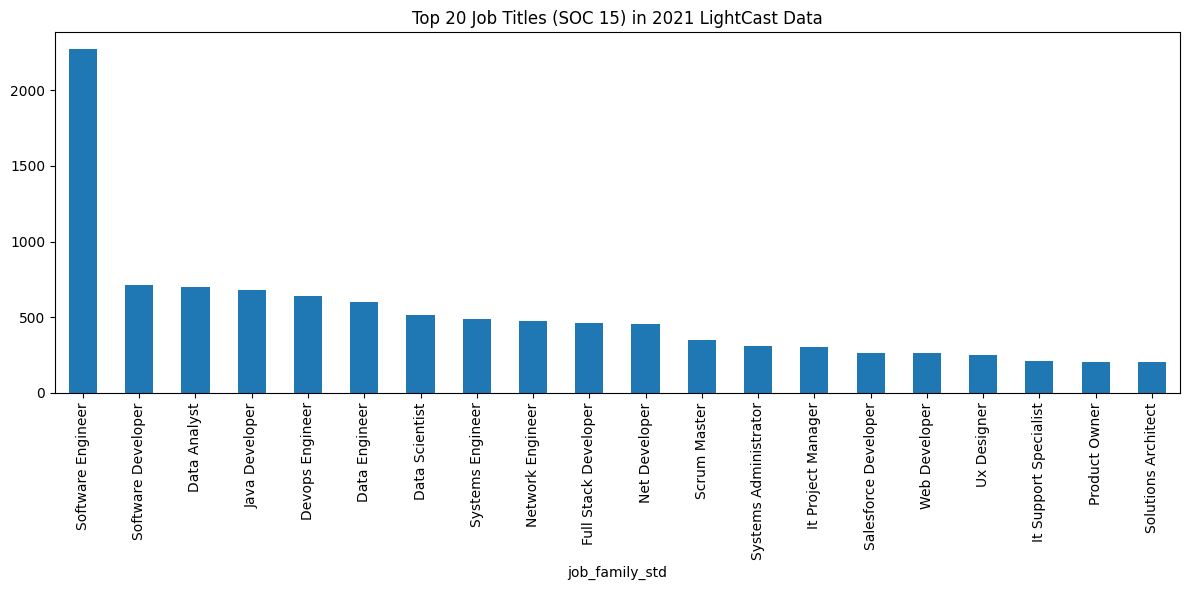

In [6]:
df['START_DATE'] = pd.to_datetime(df['POSTED'], errors='coerce')
df_2021 = df[df['START_DATE'].dt.year == 2021].copy()

plt.figure(figsize=(12,6))
df_2021['job_family_std'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Job Titles (SOC 15) in 2021 LightCast Data')
plt.tight_layout()
plt.show()

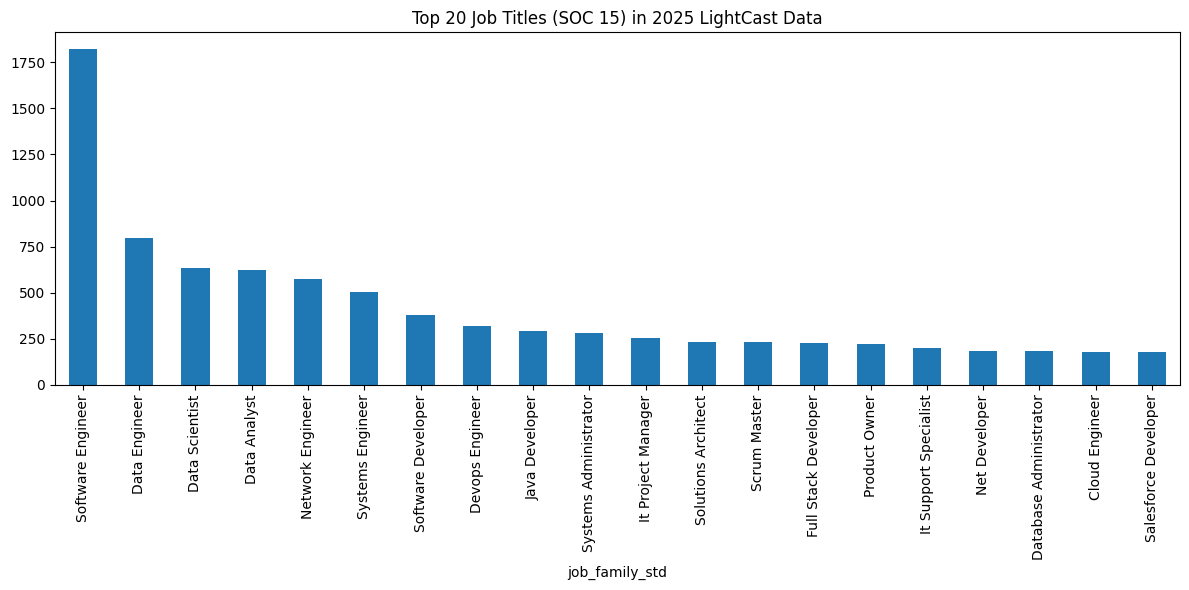

In [7]:
df_2025 = df[df['START_DATE'].dt.year == 2025].copy()

plt.figure(figsize=(12,6))
df_2025['job_family_std'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Job Titles (SOC 15) in 2025 LightCast Data')
plt.tight_layout()
plt.show()

Jobs with Largest Growth:
* jobs that existed in both 2021 and 2025, but have grown the largest amount, as a %
* jobs that are new in 2025

In [8]:
counts_2021 = df_2021['job_family_std'].value_counts().rename('count_2021')
counts_2025 = df_2025['job_family_std'].value_counts().rename('count_2025')

jobs_growth = pd.concat([counts_2021, counts_2025], axis=1, join='inner')

jobs_growth = jobs_growth[(jobs_growth['count_2021'] >= 10) & (jobs_growth['count_2025'] >= 10)].copy()
jobs_growth = jobs_growth[jobs_growth['count_2025'] > jobs_growth['count_2021']].copy()

jobs_growth['raw_growth'] = jobs_growth['count_2025'] - jobs_growth['count_2021']
jobs_growth['pct_growth'] = (jobs_growth['raw_growth'] / jobs_growth['count_2021']) * 100

top_10_jobs_growth = (
    jobs_growth
    .sort_values('pct_growth', ascending=False)
    .head(10)
    .reset_index(names='job_family_std')
)

top_10_jobs_growth['pct_growth'] = top_10_jobs_growth['pct_growth'].round(2)

top_10_jobs_growth[['job_family_std', 'count_2021', 'count_2025', 'raw_growth', 'pct_growth']]

,job_family_std,count_2021,count_2025,raw_growth,pct_growth
0,Revenue Integrity Analyst,11,34,23,209.09
1,Director Data Science,12,33,21,175.00
2,Actuary,16,42,26,162.50
3,Reliability Engineer,20,51,31,155.00
4,Machine Learning Engineer,67,162,95,141.79
5,Continuous Improvement Specialist,11,26,15,136.36
6,Cybersecurity Architect,10,23,13,130.00
7,Cybersecurity,10,23,13,130.00
8,Information Systems Security Officer,10,23,13,130.00
9,Cybersecurity Engineer,37,85,48,129.73


In [9]:
counts_2021 = df_2021['job_family_std'].value_counts().rename('count_2021')
counts_2025 = df_2025['job_family_std'].value_counts().rename('count_2025')

jobs_new_2025 = pd.concat([counts_2021, counts_2025], axis=1).fillna(0)
jobs_new_2025[['count_2021', 'count_2025']] = jobs_new_2025[['count_2021', 'count_2025']].astype(int)

jobs_new_2025 = jobs_new_2025[(jobs_new_2025['count_2021'] == 0) & (jobs_new_2025['count_2025'] >= 10)].copy()

jobs_new_2025['raw_growth'] = jobs_new_2025['count_2025'] - jobs_new_2025['count_2021']
jobs_new_2025['pct_growth'] = pd.NA  # undefined when baseline is zero

top_10_new_2025 = (
    jobs_new_2025
    .sort_values('count_2025', ascending=False)
    .head(10)
    .reset_index(names='job_family_std')
)

top_10_new_2025[['job_family_std', 'count_2021', 'count_2025', 'raw_growth', 'pct_growth']]

,job_family_std,count_2021,count_2025,raw_growth,pct_growth
0,Geek Squad Agent Retail Store,0,100,100,<NA>
1,Full Time Sales Specialist Proservices Day,0,61,61,<NA>
2,Ai Architect,0,45,45,<NA>
3,Apple Genius It Support Technician,0,21,21,<NA>
4,Software Development Engineer Software Develop...,0,21,21,<NA>
5,Ai Developer,0,21,21,<NA>
6,Ml Engineer,0,21,21,<NA>
7,Civil Design Engineer Data Centers,0,20,20,<NA>
8,Global Applications Cybersecurity Specialist,0,20,20,<NA>
9,Apple Technical Specialist Part Time,0,20,20,<NA>


Tier 2 A vs. B distinctions via 2-step process:
* Step 1: Keyword matching — broad category signal from job titles
* Step 2: Sentence-transformer matching — uses top keyword-matched titles as anchor titles and assigns the closest category based on embedding similarity

    --Keyword mapping is the primary signal; sentence-transformer matching fills gaps and provides a second opinion for confidence scoring.

Keywords for each category, built from various sources: 
* Bloomberg AI Value Chain Index
* Global AI Barometer: 2025 Report
* NVIDIA H1B listings

In [10]:
# Category A keywords
KEYWORDS_A = [
"scrum master",
"data scientist",
"machine learning engineer",
"artificial intelligence engineer",
"software engineer",
"solutions architect",
"artificial intelligence architect",
"machine learning data scientist",
"neural network",
"tensorflow",
"pytorch",
"deep learning researcher",
"software developer",
"reinforcement learning",
"multi-modal AI systems",
"NLP",
"NLP specialist",
"Senior Systems Software Engineers",
"Software Engineers",
"java",
"cloud",
"iaas",
"infastructure-as-a-service",
"paas",
"platform-as-a-service",
"llm",
"large language model",
"generative ai",
"genai",
"model developer",
"AI/ML Inference",
"Weka",
"Advanced Driver Assistance Systems",
"Applications Of Artificial Intelligence",
"Autonomous Cruise Control Systems",
"Artificial General Intelligence",
"Artificial Intelligence",
"Autonomous System",
"Autonomous Vehicles",
"Artificial Intelligence Development",
"Guidance Navigation And Control Systems",
"Artificial Intelligencble Markup Language (AIML)",
"Light Detection And Ranging (LiDAR)",
"OpenCV",
"Path Analysis",
"Path Finding",
"Remote Sensing",
"Unmanned Aerial Systems (UAS)",
"AdaBoost (Adaptive Boosting)",
"Adversarial Machine Learning",
"Apache MADlib",
"Apache Mahout",
"Apache SINGA",
"Apache Spark",
"Association Rule Learning",
"Attention Mechanisms",
"Automated Machine Learning",
"Autonomic Computing",
"Boltzmann Machine",
"Boosting",
"Bot Framework",
"Artificial Intelligence Systems",
"Baidu",
"Cognitive Automation",
"Cognitive Computing",
"Computational Intelligence",
"Cortana",
"Ethical AI",
"Expert Systems",
"Explainable AI (XAI)",
"Intelligent Control",
"Intelligent Systems",
"Interactive Kiosk",
"IPSoft Amelia",
"Multi-Agent Systems",
"Open Neural Network Exchange (ONNX)",
"OpenAI Gym",
"Operationalizing AI",
"Reasoning Systems",
"Soft Computing",
"Swarm Intelligence",
"Watson Conversation",
"Watson Studio",
"Dask (Software)",
"Data Classification",
"Dbscan",
"Decision Models",
"Decision Tree Learning",
"Dimensionality Reduction",
"Dlib (C++ Library)",
"Embedded Intelligence",
"Ensemble Methods",
"Evolutionary Programming",
"Expectation Maximization Algorithm",
"Fast.ai",
"Feature Engineering",
"Feature Extraction",
"Feature Learning",
"Feature Selection",
"Game Ai",
"Gaussian Process",
"Genetic Algorithm",
"Gradient Boosting",
"H2O.ai",
"Hidden Markov Model",
"Hyperparameter Optimization",
"Inference Engine",
"K-Means Clustering",
"Kernel Methods",
"Classification And Regression Tree (CART)",
"Cluster Analysis",
"Collaborative Filtering",
"Confusion Matrix",
"Cyber-Physical Systems",
"LIBSVM",
"Loss Functions",
"Machine Learning",
"Machine Learning Algorithms",
"Machine Learning Methods",
"Machine Learning Model Monitoring And Evaluation",
"Machine Learning Model Training",
"Markov Chain",
"Matrix Factorization",
"Meta Learning",
"Microsoft Cognitive Toolkit (CNTK)",
"MLflow",
"mlpack (C++ Library)",
"Naive Bayes Classifier",
"Objective Function",
"Perceptron",
"Predictionio",
"Programmatic Media Buying",
"Pydata",
"PyTorch (Machine Learning Library)",
"Random Forest Algorithm",
"Recommender Systems",
"Reinforcement Learning",
"Scikit-Learn (Python Package)",
"Semi-Supervised Learning",
"Sorting Algorithm",
"Supervised Learning",
"Support Vector Machine",
"Test Datasets",
"Torch (Machine Learning)",
"Training Datasets",
"Transfer Learning",
"Unsupervised Learning",
"Variational Autoencoders",
"Vowpal Wabbit",
"Xgboost",
"Amazon Alexa",
"Amazon Textract",
"ANTLR",
"Apache OpenNLP",
"BERT (NLP Model)",
"Chatbot",
"Speech Recognition",
"Speech Recognition Software",
"Speech Synthesis",
"Statistical Language Acquisition",
"Text Mining",
"Text-To-Speech",
"Theano (Software)",
"Tokenization",
"Computational Linguistics",
"Voice Assistant Technology",
"DeepSpeech",
"Dialog Systems",
"fastText",
"Fuzzy Logic",
"Handwriting Recognition",
"Hugging Face (NLP Framework)",
"Intelligent Agent",
"Intelligent Virtual Assistant",
"Kaldi",
"Language Model",
"Latent Dirichlet Allocation",
"Lexalytics",
"Machine Translation",
"Microsoft LUIS",
"Natural Language Generation",
"Natural Language Processing (NLP)",
"Natural Language Programming",
"Natural Language Toolkits",
"Natural Language Understanding",
"Natural Language User Interface",
"Nearest Neighbour Algorithm",
"Nuance Mix",
"Optical Character Recognition (OCR)",
"Prompt Engineering",
"Screen Reader",
"Semantic Analysis",
"Semantic Interpretation For Speech Recognition",
"Semantic Parsing",
"Semantic Search",
"Sentiment Analysis",
"Seq2Seq",
"Shogun",
"Voice Interaction",
"Voice User Interface",
"Word Embedding",
"Word2Vec Models",
"Apache MXNet",
"Artificial Neural Networks",
"Autoencoders",
"Caffe (Framework)",
"Caffe2",
"Chainer (Deep Learning Framework)",
"Convolutional Neural Networks",
"Cudnn",
"Deep Learning",
"Deep Learning Methods",
"Deeplearning4j",
"Evolutionary Acquisition Of Neural Topologies",
"Generative Artificial Intelligence",
"ChatGPT",
"Hugging Face Transformers",
"Large Language Modelling",
"Transformer (Machine Learning Model)",
"Generative Adversarial Networks",
"Keras (Neural Network Library)",
"Long Short-Term Memory (LSTM)",
"OpenVINO",
"PaddlePaddle",
"Pybrain",
"PyTorch Lightning",
"Recurrent Neural Network (RNN)",
"TensorFlow",
"Advanced Robotics",
"Cognitive Robotics",
"Motion Planning",
"Robot Framework",
"Robotic Automation Software",
"Robotic Liquid Handling Systems",
"Robotic Programming",
"Robotic Systems",
"Servomotor",
"Object Tracking",
"Adobe Sensei",
"Embedded AI",
"Deep Reinforcement Learning (DRL)",
"Vespa",
"CrewAI",
"Neuro-Symbolic AI",
"Incremental Learning",
"Language Models",
"SLAM Algorithms (Simultaneous Localization And Mapping)",
"Neural Ordinary Differential Equations",
"3D Reconstruction",
"Activity Recognition",
"Computer Vision",
"Contextual Image Classification",
"Deck.gl",
"Digital Image Processing",
"Eye Tracking",
"Face Detection",
"Facial Recognition",
"Image Super-Resolution",
"Sequence-to-Sequence Models (Seq2Seq)",
"Recurrent Neural Networks (RNNs)",
"Bagging Techniques",
"Data Version Control (DVC)",
"Convolutional Neural Networks (CNN)",
"Topological Data Analysis (TDA)",
"Residual Networks (ResNet)",
"Reinforcement Learning from Human Feedback (RLHF)",
"General-Purpose Computing On Graphics Processing Units",
"Variational Autoencoders (VAEs)",
"Gesture Recognition",
"Image Analysis",
"Image Matching",
"Image Recognition",
"Image Segmentation",
"Image Sensor",
"Imagenet",
"Machine Vision",
"Mnist",
"Motion Analysis",
"Object Recognition",
"OmniPage",
"Pose Estimation",
"Realsense",
"AI Copywriting",
"Conversational AI",
"Predictive Modeling",
"Synthetic Data Generation",
"OpenAI Gym Environments",
"Text Retrieval Systems",
"Scene Understanding",
"Meta-Reinforcement Learning",
"Reinforcement Learning (RL)",
"Concept Drift Detection",
"Text to Speech (TTS)",
"Thermal Imaging Analysis",
"Image Captioning",
"Meta-Learning",
"Image Inpainting",
"Digital Twin Technology",
"Semantic Kernel",
"Text Summarization",
"Natural Language Understanding (NLU)",
"Natural Language Generation (NLG)",
"Retrieval Augmented Generation",
"Dynamic Routing",
"Multimodal Learning",
"Qdrant",
"Sentence Transformers",
"Weaviate",
"Microsoft Copilot",
"Automated Data Cleaning",
"Neural Architecture Compression",
"Langgraph",
"Instance Segmentation",
"Summarization Methods",
"Bayesian Belief Networks",
"Small Language Model",
"AutoGen",
"Neural Architecture Search (NAS)",
"Graph Neural Networks (GNNs)",
"PineCone",
"Spiking Neural Networks",
"Multimodal Models",
"Gradient Boosting Machines (GBM)",
"AI Personalization",
"Support Vector Machines (SVM)",
"Federated Learning",
"Artificial Intelligence Risk",
"Agentic Systems",
"AI Testing",
"Generative AI Agents",
"DALL-E Image Generator",
"Stable Diffusion",
"Amazon Comprehend",
"Amazon Lex",
"Amazon Polly",
"Disambiguation",
"GPT-3 (NLP Model)",
"Information Extraction",
"Language Identification",
"Lemmatization",
"N Gram",
"Named Entity Recognition",
"NLTK (NLP Analysis)",
"Part-of-Speech Tagging",
"Question Answering",
"Relationship Extraction",
"Sirikit",
"Speech Enhancement",
"Speech Processing",
"Speech Technology",
"Sphinx Speech Recognition",
"Text Classification",
"Voice Technology",
"Word-Sense Disambiguation",
"K-Nearest Neighbors Algorithm",
"Artificial Consciousness",
"LightGBM",
"Intelligent Automation",
"Nuance Nina Virtual Assistant",
"Automated Planning And Scheduling",
"LangChain",
"GitHub Copilot",
"Human AI Interaction",
"Few Shot Learning",
"AI Research",
"AI Innovation",
"AI Agents",
"Agentic AI",
"Zero Shot Learning",
"AI Safety",
"AI Alignment",
"Graph Algorithms",
"Time Series",
"Text Processing",
"Neural Machine Translation (NMT)"
]

# Category B: Hardware & Infrastructure 
KEYWORDS_B = [
"hardware",
"semiconductor",
"hyperscaler",
"tpu",
"tensor processing unit",
"fpga",
"field-programmable gate array",
"it systems analyst",
"information technology",
"IT",
"database administrator",
"data center",
"ASIC Engineers",
"CAD Engineers",
"DevOps Engineers",
"Hardware Engineers",
"Engineering Managers",
"Mask Design Engineers",
"Mechanical Engineers",
"Mixed Signal Design Engineers",
"Physical Design Engineers",
"Senior ASIC Engineers",
"Software QA Engineers",
"System Design Engineers",
"Systems Software Managers",
"Test Engineers",
"Verification Engineers",
"gpu",
"graphics processing unit",
"sql",
"AIOps (Artificial Intelligence For IT Operations)",
"AWS SageMaker",
"Azure Machine Learning",
"Azure Cognitive Services",
"Knowledge Engineering",
"Knowledge-Based Configuration",
"Knowledge-Based Systems",
"Google AutoML",
"Google Cloud ML Engine",
"Kubeflow",
"MLOps (Machine Learning Operations)",
"ModelOps",
"Oracle Autonomous Database",
"Nvidia Jetson",
"Robot Operating Systems",
"t-SNE (t-distributed Stochastic Neighbor Embedding)",
"Distributed Machine Learning",
"Knowledge Representation",
"Edge Intelligence",
"Knowledge Distillation",
"AI Security",
"Google Bard",
"Dialogflow (Google Service)",
"Azure OpenAI",
"Azure AI Studio",
"AWS Bedrock",
"Google Assistant",
"PySpark",
"Databricks"
]
ALL_TIER2_KEYWORDS = KEYWORDS_A + KEYWORDS_B

Helper functions:
* Keyword matching -- scan title for category keywords
* Sentence-transformer matching -- compare each title to top keyword-matched anchor titles
* assign_category / assign_confidence -- combine signals into final label

In [11]:
def keyword_match(title):
    """Return category if title contains a Tier 2 keyword, else None."""
    title_text = "" if pd.isna(title) else str(title)
    text = title_text.lower()

    for kw in KEYWORDS_B:   # Check B first — more specific infrastructure terms
        if kw.lower() in text:
            return "B"
    for kw in KEYWORDS_A:
        if kw.lower() in text:
            return "A"
    return None

In [12]:
def assign_category(kw_cat, embedding_cat):
    """Keyword mapping dominates; embedding matching fills in where keyword has no match."""
    has_kw = pd.notna(kw_cat)
    has_embedding = pd.notna(embedding_cat)

    if has_kw:
        return kw_cat
    if has_embedding:
        return embedding_cat
    return None

In [13]:
def assign_confidence(kw_cat, embedding_cat):
    """
    high: keyword and embedding match both mapped and agree.
    medium: only one signal, or both map but disagree.
    """
    has_kw = pd.notna(kw_cat)
    has_embedding = pd.notna(embedding_cat)

    if has_kw and has_embedding and kw_cat == embedding_cat:
        return "high"
    if has_kw or has_embedding:
        return "medium"
    return None

Run pipeline

In [14]:
# Set up -- change as needed.
TITLE_COL = 'job_family_std'
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_SIMILARITY_THRESHOLD = 0.55
OUTPUT_CSV = "lightcast_tier2_classified.csv"

In [15]:
# --- Stage 1: Keyword Matching (title only) ---
print("\nStage 1: Keyword matching (title only)...")
df["_KW_CAT"] = df[TITLE_COL].apply(keyword_match)
df["TIER2_KEYWORD_MATCH"] = df["_KW_CAT"].notna()
print(f"  {df['TIER2_KEYWORD_MATCH'].sum():,} matches")


Stage 1: Keyword matching (title only)...
  84,545 matches


## Stage 2: Extract LLM Anchor Titles from Keyword Results

In [16]:
# Build one category per title based on dominant keyword label
kw_matched = df[df["_KW_CAT"].notna()].copy()

title_cat_counts = (
    kw_matched
    .groupby(["job_family_std", "_KW_CAT"])
    .size()
    .unstack(fill_value=0)
)

for col in ["A", "B"]:
    if col not in title_cat_counts.columns:
        title_cat_counts[col] = 0

title_cat_counts["total"] = title_cat_counts["A"] + title_cat_counts["B"]
title_cat_counts["dominant_cat"] = np.where(
    title_cat_counts["A"] >= title_cat_counts["B"], "A", "B"
)
title_cat_counts["dominant_share"] = np.where(
    title_cat_counts["dominant_cat"] == "A",
    title_cat_counts["A"] / title_cat_counts["total"],
    title_cat_counts["B"] / title_cat_counts["total"],
)

# Keep stronger assignments only; lower this threshold to include more titles
strong_titles = title_cat_counts[title_cat_counts["dominant_share"] >= 0.60].copy()

# Build ranked top-25 tables WITH counts (not just first 25 rows)
top_anchors_A_counts = (
    strong_titles[strong_titles["dominant_cat"] == "A"]["A"]
    .sort_values(ascending=False)
    .head(25)
)

top_anchors_B_counts = (
    strong_titles[strong_titles["dominant_cat"] == "B"]["B"]
    .sort_values(ascending=False)
    .head(25)
)

# Lists used by the LLM prompt
top_anchors_A = top_anchors_A_counts.index.tolist()
top_anchors_B = top_anchors_B_counts.index.tolist()

print(f"Category A anchors ({len(top_anchors_A)}):")
print(top_anchors_A_counts.to_string())

print(f"\nCategory B anchors ({len(top_anchors_B)}):")
print(top_anchors_B_counts.to_string())

# Quick sanity check: should always be empty
overlap = sorted(set(top_anchors_A).intersection(set(top_anchors_B)))
print(f"\nOverlap count: {len(overlap)}")
if overlap:
    print("Overlapping titles:")
    for t in overlap:
        print(f"  {t}")

Category A anchors (25):
job_family_std
Software Engineer                 4093
Data Scientist                    1148
Software Developer                1090
Java Developer                     973
Scrum Master                       582
Cloud Engineer                     338
Machine Learning Engineer          229
Full Stack Software Engineer       215
Embedded Software Engineer         198
Software Engineer Remote           155
Software Engineer Manager          147
Software Engineer Full Stack       125
Java Full Stack Developer          125
Full Stack Java Developer          118
Java Software Engineer             113
Manager Software Engineer           99
Java Engineer                       92
Software Engineer Java              90
Entry Level Software Developer      77
Director Software Engineer          77
Software Engineer I                 77
Entry Level Software Engineer       77
Entry Level Java Developer          76
Java Backend Developer              68
Software Engineer Backen

## Stage 3: Sentence-Transformer Classification

In [17]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

ST_BATCH_SIZE = 256
embedding_model = SentenceTransformer(EMBEDDING_MODEL)

def classify_titles_with_embeddings(titles, anchors_a, anchors_b, similarity_threshold=EMBEDDING_SIMILARITY_THRESHOLD):
    """
    Classify titles as A, B, or None using the closest anchor-title embedding.
    Returns a dict mapping title -> category string or None.
    """
    anchor_titles = anchors_a + anchors_b
    anchor_labels = (["A"] * len(anchors_a)) + (["B"] * len(anchors_b))

    if not titles or not anchor_titles:
        return {title: None for title in titles}

    anchor_embeddings = embedding_model.encode(
        anchor_titles,
        batch_size=ST_BATCH_SIZE,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    title_embeddings = embedding_model.encode(
        titles,
        batch_size=ST_BATCH_SIZE,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )

    similarity_matrix = cos_sim(title_embeddings, anchor_embeddings)
    result = {}

    for index, title in enumerate(titles):
        row_scores = similarity_matrix[index]
        best_anchor_index = int(row_scores.argmax().item())
        best_score = float(row_scores[best_anchor_index].item())

        if best_score < similarity_threshold:
            result[title] = None
            continue

        result[title] = anchor_labels[best_anchor_index]

    return result

c:\Users\linds\repos\DoE_CM_Exploration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1896.89it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Run sentence-transformer classification over all unique job titles
print("\nStage 3: Sentence-transformer classification...")
unique_titles = df[TITLE_COL].dropna().unique().tolist()
embedding_results = classify_titles_with_embeddings(
    unique_titles,
    top_anchors_A,
    top_anchors_B,
    similarity_threshold=EMBEDDING_SIMILARITY_THRESHOLD,
 )

df["_EMBEDDING_CAT"] = df[TITLE_COL].map(embedding_results)
print(f"  Embedding matches: {df['_EMBEDDING_CAT'].notna().sum():,} rows")

if df["_EMBEDDING_CAT"].notna().sum() == 0:
    print("No embedding-based classifications found.")
    print("Try lowering EMBEDDING_SIMILARITY_THRESHOLD, for example to 0.50 or 0.45.")


Stage 3: Sentence-transformer classification...


In [ ]:
# Build row-level classification columns
df["TIER2_KEYWORD_CATEGORY"] = df["_KW_CAT"]
df["TIER2_EMBEDDING_CATEGORY"] = df["_EMBEDDING_CAT"]
df["TIER2_CATEGORY"] = df.apply(lambda row: assign_category(row["_KW_CAT"], row["_EMBEDDING_CAT"]), axis=1)
df["TIER2_CONFIDENCE"] = df.apply(lambda row: assign_confidence(row["_KW_CAT"], row["_EMBEDDING_CAT"]), axis=1)

# Output distinct job-title mapping view: keyword result, embedding result, final category, confidence
classification_df = (
    df[["job_titles_std", "TIER2_KEYWORD_CATEGORY", "TIER2_EMBEDDING_CATEGORY", "TIER2_CATEGORY", "TIER2_CONFIDENCE"]]
    .drop_duplicates()
    .sort_values(["job_titles_std", "TIER2_CATEGORY"], na_position="last")
 )
classification_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(classification_df):,} unique job title classifications to {OUTPUT_CSV}")

Saved 118,935 unique job title classifications to lightcast_tier2_classified.csv


In [ ]:
#Summarize how many job titles were classified into each category and confidence level
summary = (
    df[["job_titles_std", "TIER2_CATEGORY", "TIER2_CONFIDENCE"]]
      .drop_duplicates()
      .groupby(["TIER2_CATEGORY", "TIER2_CONFIDENCE"], dropna=False)
      .size()
      .reset_index(name="count")
)
print("\nSummary of Tier 2 classifications:")
print(summary.to_string(index=False))



Summary of Tier 2 classifications:
TIER2_CATEGORY TIER2_CONFIDENCE  count
             A             high  11130
             A           medium  16143
             B             high  17195
             B           medium  31580
           NaN              NaN  42885


In [ ]:
#Print top 25 job titles classified to A and B (top 25 as count)
print("\nTop 25 job titles classified as Category A:")
print(df[df["TIER2_CATEGORY"] == "A"]["job_titles_std"].value_counts().head(25))
print("\nTop 25 job titles classified as Category B:")
print(df[df["TIER2_CATEGORY"] == "B"]["job_titles_std"].value_counts().head(25))



Top 25 job titles classified as Category A:
job_titles_std
Software Engineer              1431
Senior Software Engineer        940
Data Analyst                    900
Data Engineer                   661
Devops Engineer                 599
Software Developer              590
Data Scientist                  565
Java Developer                  541
Scrum Master                    436
Net Developer                   432
Full Stack Developer            424
Systems Engineer                422
Sr Software Engineer            310
Salesforce Developer            300
Senior Data Engineer            295
Web Developer                   252
Principal Software Engineer     211
Senior Data Scientist           205
Senior Devops Engineer          188
Lead Software Engineer          187
Python Developer                186
Cloud Engineer                  183
Software Engineer Ii            181
Senior Systems Engineer         176
Full Stack Engineer             169
Name: count, dtype: int64

Top 25 job ti

In [ ]:
# Top 25 job titles classified as A and B with high confidence (keyword and embedding agree)
print("\nTop 25 job titles classified as Category A with high confidence:")
print(df[(df["TIER2_CATEGORY"] == "A") & (df["TIER2_CONFIDENCE"] == "high")]["job_titles_std"].value_counts().head(25))
print("\nTop 25 job titles classified as Category B with high confidence:")
print(df[(df["TIER2_CATEGORY"] == "B") & (df["TIER2_CONFIDENCE"] == "high")]["job_titles_std"].value_counts().head(25))


Top 25 job titles classified as Category A with high confidence:
job_titles_std
Software Engineer               1431
Senior Software Engineer         940
Software Developer               590
Data Scientist                   565
Java Developer                   541
Scrum Master                     436
Sr Software Engineer             310
Principal Software Engineer      211
Senior Data Scientist            205
Lead Software Engineer           187
Cloud Engineer                   183
Software Engineer Ii             181
Staff Software Engineer          145
Senior Java Developer            144
Embedded Software Engineer       138
Senior Software Developer        136
Software Engineer Iii            135
Machine Learning Engineer        124
Software Engineering Manager     114
Sr Java Developer                104
Junior Software Developer         99
Java Full Stack Developer         97
Fullstack Software Engineer       83
Full Stack Software Engineer      82
Full Stack Java Developer      

In [ ]:
# Top 25 job titles in each category with medium confidence (only one signal or signals disagree)
#print methods that classify them
print("\nTop 25 job titles classified as Category A with medium confidence:")   
print(df[(df["TIER2_CATEGORY"] == "A") & (df["TIER2_CONFIDENCE"] == "medium")]["job_titles_std"].value_counts().head(25))
print("\nTop 25 job titles classified as Category B with medium confidence:")
print(df[(df["TIER2_CATEGORY"] == "B") & (df["TIER2_CONFIDENCE"] == "medium")]["job_titles_std"].value_counts().head(25))




Top 25 job titles classified as Category A with medium confidence:
job_titles_std
Data Analyst               900
Data Engineer              661
Devops Engineer            599
Net Developer              432
Full Stack Developer       424
Systems Engineer           422
Salesforce Developer       300
Senior Data Engineer       295
Web Developer              252
Senior Devops Engineer     188
Python Developer           186
Senior Systems Engineer    176
Full Stack Engineer        169
Front End Developer        158
Application Developer      147
Senior Data Analyst        145
Android Developer          143
Backend Engineer           132
Sr Data Engineer           121
Developer                  119
Application Engineer       113
Ios Developer              107
Programmer Analyst          99
Application Programmer      99
Frontend Engineer           98
Name: count, dtype: int64

Top 25 job titles classified as Category B with medium confidence:
job_titles_std
Network Engineer                 

# New Vs. Existing Jobs in Tier 2 A and B

In [ ]:
# Top-share job titles in Tier 2 A/B for 2021, 2025, and jobs new in 2025
TOP_N = 10
TITLE_FOR_SHARE = "job_family_std"

# Ensure we are using classified data with dates
analysis_df = df.copy()
analysis_df["START_DATE"] = pd.to_datetime(analysis_df["POSTED"], errors="coerce")
analysis_df = analysis_df.dropna(subset=["START_DATE", TITLE_FOR_SHARE, "TIER2_CATEGORY"])
analysis_df["YEAR"] = analysis_df["START_DATE"].dt.year

df_2021_t2 = analysis_df[analysis_df["YEAR"] == 2021].copy()
df_2025_t2 = analysis_df[analysis_df["YEAR"] == 2025].copy()

def top_share_within_tier(frame, tier_label, top_n=10):
    """Top titles by share within a Tier 2 subgroup."""
    tier_df = frame[frame["TIER2_CATEGORY"] == tier_label].copy()
    denom = len(tier_df)
    if denom == 0:
        return pd.DataFrame(columns=[TITLE_FOR_SHARE, "count", "share_pct"]), 0

    out = (
        tier_df[TITLE_FOR_SHARE]
        .value_counts()
        .head(top_n)
        .rename("count")
        .reset_index(names=TITLE_FOR_SHARE)
    )
    out["share_pct"] = (out["count"] / denom * 100).round(2)
    return out, denom

def plot_top_share(top_a, top_b, denom_a, denom_b, title_text):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

    # Tier A panel
    if not top_a.empty:
        plot_a = top_a.iloc[::-1]
        axes[0].barh(plot_a[TITLE_FOR_SHARE], plot_a["share_pct"], color="#1f77b4")
        axes[0].set_title(f"Tier 2A (n={denom_a:,})")
        axes[0].set_xlabel("Share of Tier 2A (%)")
    else:
        axes[0].text(0.5, 0.5, "No Tier 2A rows", ha="center", va="center")
        axes[0].set_title("Tier 2A")
        axes[0].set_xlabel("Share of Tier 2A (%)")

    # Tier B panel
    if not top_b.empty:
        plot_b = top_b.iloc[::-1]
        axes[1].barh(plot_b[TITLE_FOR_SHARE], plot_b["share_pct"], color="#ff7f0e")
        axes[1].set_title(f"Tier 2B (n={denom_b:,})")
        axes[1].set_xlabel("Share of Tier 2B (%)")
    else:
        axes[1].text(0.5, 0.5, "No Tier 2B rows", ha="center", va="center")
        axes[1].set_title("Tier 2B")
        axes[1].set_xlabel("Share of Tier 2B (%)")

    fig.suptitle(title_text, fontsize=14)
    plt.tight_layout()
    plt.show()

# 1) 2021 top-share titles in Tier 2A and Tier 2B
top_2021_a, n_2021_a = top_share_within_tier(df_2021_t2, "A", TOP_N)
top_2021_b, n_2021_b = top_share_within_tier(df_2021_t2, "B", TOP_N)
print("Top Tier 2A titles by share in 2021:")
display(top_2021_a)
print("Top Tier 2B titles by share in 2021:")
display(top_2021_b)
plot_top_share(top_2021_a, top_2021_b, n_2021_a, n_2021_b, "Top Tier 2 Job Titles by Share (2021)")

# 2) 2025 top-share titles in Tier 2A and Tier 2B
top_2025_a, n_2025_a = top_share_within_tier(df_2025_t2, "A", TOP_N)
top_2025_b, n_2025_b = top_share_within_tier(df_2025_t2, "B", TOP_N)
print("Top Tier 2A titles by share in 2025:")
display(top_2025_a)
print("Top Tier 2B titles by share in 2025:")
display(top_2025_b)
plot_top_share(top_2025_a, top_2025_b, n_2025_a, n_2025_b, "Top Tier 2 Job Titles by Share (2025)")

# 3) New-in-2025 titles (not present in 2021), then top-share within Tier 2A and Tier 2B
titles_2021 = set(df_2021_t2[TITLE_FOR_SHARE].dropna().astype(str).unique())
new_2025_df = df_2025_t2[~df_2025_t2[TITLE_FOR_SHARE].astype(str).isin(titles_2021)].copy()

top_new_2025_a, n_new_2025_a = top_share_within_tier(new_2025_df, "A", TOP_N)
top_new_2025_b, n_new_2025_b = top_share_within_tier(new_2025_df, "B", TOP_N)
print("Top NEW Tier 2A titles by share in 2025 (absent in 2021):")
display(top_new_2025_a)
print("Top NEW Tier 2B titles by share in 2025 (absent in 2021):")
display(top_new_2025_b)
plot_top_share(
    top_new_2025_a,
    top_new_2025_b,
    n_new_2025_a,
    n_new_2025_b,
    "Top NEW Tier 2 Job Titles by Share (2025 only, not in 2021)",
)

TypeError: Series.reset_index() got an unexpected keyword argument 'names'. Did you mean 'name'?

First, we have to make assumptions about Tier sizes among the universe of LightCast postings
* All LightCast postings in 2025: 42.1 million
* Tier 1: Assuming 0.1% of postings
* Tier 2: Assuming 3.5% of postings'
* Tier 3: Assuming 35% of postings

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

def calculate_n(p1, relative_shift, alpha=0.05, power=0.80):
    """
    Calculates sample size (n per year) to detect a relative shift in a proportion.

    Args:
        p1:             baseline proportion (e.g. 0.035 for 3.5%)
        relative_shift: e.g. 0.05 = detect a 5% relative increase (p1 -> p1 * 1.05)
        alpha:          significance level (default 0.05)
        power:          target power (default 0.80)

    Returns:
        n_per_year: postings needed per year (each year treated as one group)
    """
    p2 = p1 * (1 + relative_shift)

    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)

    p_avg = (p1 + p2) / 2

    num = (z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) +
           z_beta  * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
    den = (p1 - p2) ** 2

    # Total n split equally across the two years being compared
    n_per_year = int(np.ceil(num / den / 2))

    return n_per_year


# ── Assumptions (update these) ────────────────────────────────────────────────

tiers = {
    "Tier 1 (Innovators)": 0.001,
    "Tier 2 (Enablers)":   0.035,
    "Tier 3 (Augmented)":  0.350,
}

shifts = [0.05, 0.10]   # relative shifts to detect

# ── Run ───────────────────────────────────────────────────────────────────────

results = []
for name, p_base in tiers.items():
    row = {"Tier": name, "Baseline %": f"{p_base*100:.1f}%"}
    for s in shifts:
        n = calculate_n(p_base, s)
        row[f"n/year ({int(s*100)}% relative shift)"] = f"{n:,}"
    results.append(row)

print("POWER ANALYSIS — POSTINGS NEEDED PER YEAR TO DETECT TIER SHIFTS")
print("=" * 70)
print(f"Alpha=0.05, Power=0.80. Shifts are relative (e.g. 5% of baseline).\n")
print(pd.DataFrame(results).to_string(index=False))